# Point particles in CMEMS Baltic currents

Proof of concept for the Parcels + CMEMS pipeline. We load hourly Baltic Sea physics from the Copernicus Marine Service, build a Parcels FieldSet, and advect point particles at three depth levels in the Kiel Bight using AdvectionRK4.

No drifter model here -- just passive point particles tracking the Eulerian flow.

## Imports

In [ ]:
import shutil
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode
from parcels.kernels import AdvectionRK4

## Parameters

In [ ]:
N_PARTICLES = 20
LON_MIN = 10.0
LON_MAX = 11.0
LAT_MIN = 54.3
LAT_MAX = 54.6
RANDOM_SEED = 42
DEPTH_INDICES = [0, 1, 3]
DT = 300.0
RUNTIME = 172800.0  # 48 hours
OUTPUTDT = 3600.0
OUTPUT_DIR = "output"
CMEMS_DIR = "data/cmems"

## Load CMEMS data

We open the CMEMS Baltic Sea physics analysis/forecast product (hourly, native grid) and subset to the Kiel Bight region. Only the velocity components `uo` and `vo` are needed.

In [ ]:
ds_sub = xr.open_dataset(CMEMS_DIR + "/cmems_mod_bal_phy_anfc_PT1H-i.nc").sel(
    longitude=slice(9.5, 11.5),
    latitude=slice(54.0, 55.5),
    time=slice("2023-04-24", "2023-04-27"),
)

# Rename to Parcels convention, fill land (NaN) with zero velocity
ds_sub = ds_sub.rename({"uo": "U", "vo": "V"}).fillna(0.0)

ds_sub = ds_sub.load()
ds_sub

## Build FieldSet

The CMEMS dataset does not include SGRID metadata, so we add a minimal `grid` variable with the required `cf_role` and dimension mappings. The coordinate `axis` attributes (X, Y, Z, T) are already present from the Copernicus Marine toolbox.

In [3]:
ds_sub["grid"] = xr.DataArray(
    data=0,
    attrs={
        "cf_role": "grid_topology",
        "topology_dimension": 2,
        "node_dimensions": "longitude latitude",
        "face_dimensions": (
            "longitude:longitude (padding: none) "
            "latitude:latitude (padding: none)"
        ),
        "vertical_dimensions": "depth:depth (padding: none)",
        "node_coordinates": "longitude latitude",
    },
)

fieldset = FieldSet.from_sgrid_conventions(ds_sub, mesh="spherical")
fieldset

<FieldSet>
    fields:
        <Field 'U'>
            Parcels attributes:
                name            : 'U'
                interp_method   : <function XLinear at 0x32e321640>
                time_interval   : TimeInterval(left=np.datetime64('2023-04-24T00:00:00.000000000'), right=np.datetime64('2023-04-27T23:00:00.000000000'))
                igrid           : -1
            DataArray:
                <xarray.DataArray 'U' (time: 96, depth: 5, latitude: 90, longitude: 72)> Size: 12MB
                0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
                Coordinates:
                  * time       (time) datetime64[ns] 768B 2023-04-24 ... 2023-04-27T23:00:00
                  * depth      (depth) float32 20B 0.5016 1.516 2.548 3.602 4.684
                  * latitude   (latitude) float32 360B 54.01 54.02 54.04 ... 55.46 55.47 55.49
                  * longitude  (longitude) float32 288B 9.514 9.542 9.569 ... 11.43 11.46 11.49
              

## Release particles

20 point particles at random positions in the southern Kiel Bight, run at three depth levels matching the CMEMS grid.

In [ ]:
DEPTHS = ds_sub.depth.values[DEPTH_INDICES].tolist()

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(RANDOM_SEED)
release_lons = rng.uniform(LON_MIN, LON_MAX, N_PARTICLES)
release_lats = rng.uniform(LAT_MIN, LAT_MAX, N_PARTICLES)

print(f"Depth levels: {[f'{d:.2f}' for d in DEPTHS]} m")
print(f"{N_PARTICLES} particles per level, {len(DEPTHS)} levels")

## Run simulation

We run AdvectionRK4 with a 5-minute timestep for 48 hours. Particles that leave the domain are deleted via a recovery kernel.

In [5]:
def DeleteOOB(particles, fieldset):
    """Delete particles that leave the domain."""
    state = np.asarray(particles.state)
    oob = (state == StatusCode.ErrorOutOfBounds) | (state == StatusCode.ErrorThroughSurface)
    if np.any(oob):
        particles.state = np.where(oob, StatusCode.Delete, state)

In [ ]:
results = {}
for depth_level in DEPTHS:
    store = str(output_dir / f"02_cmems_z{depth_level:.2f}m.zarr")
    shutil.rmtree(store, ignore_errors=True)

    pset = ParticleSet(
        fieldset=fieldset,
        pclass=Particle,
        lon=release_lons.tolist(),
        lat=release_lats.tolist(),
        z=[depth_level] * N_PARTICLES,
    )
    pset.execute(
        kernels=[AdvectionRK4, DeleteOOB],
        dt=DT,
        runtime=RUNTIME,
        output_file=ParticleFile(store=store, outputdt=OUTPUTDT),
        verbose_progress=False,
    )
    results[depth_level] = store

## Plot trajectories

Map of all trajectories, colored by depth level. Land from Natural Earth 10m.

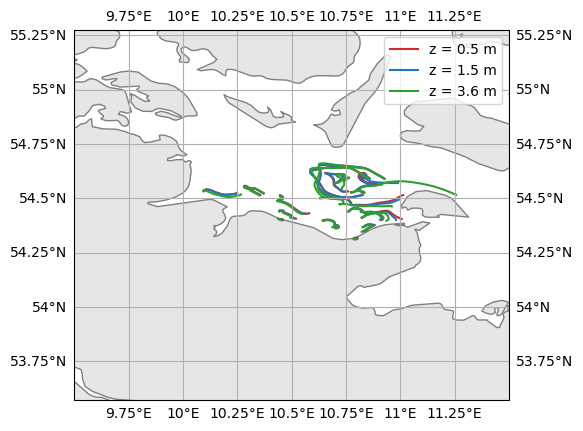

In [7]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

colors = ["tab:red", "tab:blue", "tab:green"]
for (depth_level, store), color in zip(results.items(), colors):
    ds_out = xr.open_zarr(store)
    label = f"z = {depth_level:.1f} m"
    for i in range(ds_out.sizes["trajectory"]):
        lon_i = ds_out.lon.values[i, :]
        lat_i = ds_out.lat.values[i, :]
        valid = np.isfinite(lon_i)
        ax.plot(lon_i[valid], lat_i[valid], color=color,
                label=label if i == 0 else None)

land = cfeature.NaturalEarthFeature("physical", "land", "10m",
                                     facecolor="0.9", edgecolor="0.5")
ax.add_feature(land)
ax.set_extent([9.5, 11.5, 53.8, 55.5])
ax.gridlines(draw_labels=True)
ax.legend()
plt.show()

## Summary

<!-- TODO: fill in after running the notebook -->